In [61]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import sys
import numpy as np
import discovery as ds
import numpy as np
import glob
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp
import functools
from tqdm import tqdm

from enterprise.signals import signal_base

import numpy as np
import scipy.linalg as sl
import scipy.sparse as ss
from sksparse.cholmod import cholesky
from enterprise.signals import signal_base
from enterprise.signals.gp_signals import get_timing_model_basis, BasisGP
from enterprise.signals.parameter import function
from enterprise_extensions import load_feathers


import argparse
import time

    
from enterprise.signals import selections
import enterprise.signals.parameter as parameter
from enterprise.signals import white_signals
from enterprise_extensions.blocks import common_red_noise_block
from enterprise.signals import gp_signals    
from enterprise.signals import utils
from enterprise_extensions import deterministic
from discovery.deterministic import make_phase_connected_binary

from pathlib import Path

In [62]:
# Set data product directory. The simulation code requires pulsar timing models and data to initialise. 
# In this directory, we have stored these files for a set of pulsars (mimicking the IPTA DR2 dataset, but nonetheless synthetic).

feather_dir = "./data_products/"

### Set up options

In [63]:
# The pulsar term is always injected into the data, this is referring to whether we include it in the model.
pulsar_term = True

# Realisation seed
seed = 1234
rng= np.random.default_rng(seed)
# The number of CW sources to inject
num_cw = 1

# The number of pulsars to use in the analysis (for speed, max=116 available)
Npulsars = 10

In [64]:
# Bookkeeping between the injection and diff likelihood codes
cw_block_names = ["cw" if i == 0 else f"cw{i+1}" for i in range(num_cw)]
disco_suffixes = ["" if i == 0 else f"_{i+1}" for i in range(num_cw)]

### Set up data injection

In [65]:
# Simulation code. Uses the signal objects from enterprise, an input parameter dictionary, and pulsar residuals
# and returns simulated residuals with signals drawn from the Gaussian processes defined in the PTA object.

def simulate(pta, params, sparse_cholesky=True):
    """Simulate code with enterprise (instead of libstempo/PINT)"""
    delays, ndiags, fmats, phis = (pta.get_delay(params=params),
                                   pta.get_ndiag(params=params),
                                   pta.get_basis(params=params),
                                   pta.get_phi(params=params))

    gpresiduals = []
    if pta._commonsignals:
        if sparse_cholesky:
            cf = cholesky(ss.csc_matrix(phis))
            gp = np.zeros(phis.shape[0])
            gp[cf.P()] = np.dot(cf.L().toarray(), np.random.randn(phis.shape[0]))
        else:
            gp = np.dot(sl.cholesky(phis, lower=True), np.random.randn(phis.shape[0]))

        i = 0
        for fmat in fmats:
            j = i + fmat.shape[1]
            gpresiduals.append(np.dot(fmat, gp[i:j]))
            i = j

        assert len(gp) == i
    else:
        for fmat, phi in zip(fmats, phis):
            if phi is None:
                gpresiduals.append(0)
            elif phi.ndim == 1:
                gpresiduals.append(np.dot(fmat, np.sqrt(phi) * np.random.randn(phi.shape[0])))
            else:
                raise NotImplementedError

    whiteresiduals = []
    for delay, ndiag in zip(delays, ndiags):
        if ndiag is None:
            whiteresiduals.append(0)
        elif isinstance(ndiag, signal_base.ShermanMorrison):
            # this code is very slow...
            n = np.diag(ndiag._nvec)
            for j,s in zip(ndiag._jvec, ndiag._slices):
                n[s,s] += j
            whiteresiduals.append(delay + np.dot(sl.cholesky(n, lower=True), np.random.randn(n.shape[0])))
        elif ndiag.ndim == 1:
            whiteresiduals.append(delay + np.sqrt(ndiag) * np.random.randn(ndiag.shape[0]))
        else:
            raise NotImplementedError

    return [np.array(g + w) for g, w in zip(gpresiduals, whiteresiduals)]

def set_residuals(psr, y):
    psr._residuals[psr._isort] = y

@function
def tm_prior(weights, toas, variance=1e40):
    return weights * variance * len(toas)

def TimingModel(coefficients=False, name="linear_timing_model",
                use_svd=False, normed=True, prior_variance=1e40):
    """Class factory for marginalized linear timing model signals."""

    basis = get_timing_model_basis(use_svd, normed)
    prior = tm_prior(variance=prior_variance)

    BaseClass = BasisGP(prior, basis, coefficients=coefficients, name=name)

    class TimingModel(BaseClass):
        signal_type = "basis"
        signal_name = "linear timing model"
        signal_id = name + "_svd" if use_svd else name

    return TimingModel


In [66]:
# Load the pulsars data products as Enterprise Pulsar objects
# Any DMX or p_dist errors can be ignored.
psrs = load_feathers.load_feathers_from_folder(feather_dir)

FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot fi

In [67]:
##### This code builds a simple PTA model for the simulated data including: 
# instrumental white noise, 
# pulsar intrinsic red noise (radio-frequency independent),
# a Hellings-Downs correlated gravitational wave background signal 
# and N continuous wave sources.


# The _pdist attribute is used by enterprise to store the pulsar distance. 
# Here, we back this up to allow us to vary it later. We also wipe the residuals to zero.
for psr in psrs:
    psr._pdist = psr.pdist
    psr.residuals = np.array(psr.toas) * 0.0

tmin = [p.toas.min() for p in psrs]
tmax = [p.toas.max() for p in psrs]
Tspan = np.max(tmax) - np.min(tmin)


selection = selections.Selection(selections.by_backend)
efac = parameter.Constant(1)
equad = parameter.Constant(-8)

log10_A_red = parameter.Uniform(-18, -11)
gamma_red = parameter.Uniform(0, 7)
log10_A_gw = parameter.Uniform(-18,-11)('gwb_log10_A')
gamma_gw = parameter.Uniform(0,7)('gwb_gamma')

# Number of Fourier components for red noise and GWB
components = 30

tm = TimingModel(coefficients=False, name="linear_timing_model",
                use_svd=False, normed=True, prior_variance=1e-14)
models = []
for p in psrs:
    s = tm

    ef = white_signals.MeasurementNoise(efac=efac, selection=selection)
    s += ef

    eq = white_signals.TNEquadNoise(log10_tnequad=equad, selection=selection)
    s += eq

    pl = utils.powerlaw(log10_A=log10_A_red, gamma=gamma_red)
    rn = gp_signals.FourierBasisGP(spectrum=pl, components=components, Tspan=Tspan, name="rednoise")
    s += rn

    ## HD Correlated signal
    crn = common_red_noise_block(psd='powerlaw', prior='log-uniform',
                        components=components, orf='hd', name='gwb')

    s += crn

    # CW sources
    # This is a phase-distance connected circular binary model that evolves according to GR. 
    # Both the Earth and pulsar terms are included.
    
    for name in cw_block_names:
        s += deterministic.cw_block_circ(
            amp_prior="log-uniform",
            dist_prior=None,
            skyloc=None,
            log10_fgw=None,
            psrTerm=True,
            phase_connected=True,
            discoclone=False,
            name=name,
        )

    models.append(s(p))
    print(p.name)
    
pta = signal_base.PTA(models)

pta.set_default_params({})

B1855+09
B1937+21
B1953+29
J0023+0923
J0030+0451
J0125-2327
J0340+4130
J0406+3039
J0437-4715
J0509+0856
J0557+1551
J0605+3757
J0610-2100
J0613-0200
J0614-3329
J0636+5128
J0636-3044
J0645+5158
J0709+0458
J0711-6830
J0740+6620
J0751+1807
J0900-3144
J0931-1902
J0955-6150
J1012+5307
J1012-4235
J1017-7156
J1022+1001
J1024-0719
J1036-8317
J1045-4509
J1101-6424
J1103-5403
J1125+7819
J1125-5825
J1125-6014
J1216-6410
J1312+0051
J1327-0755
J1421-4409
J1431-5740
J1435-6100
J1446-4701
J1453+1902
J1455-3330
J1525-5545
J1543-5149
J1545-4550
J1547-5709
J1600-3053
J1603-7202
J1614-2230
J1629-6902
J1630+3734
J1640+2224
J1643-1224
J1652-4838
J1653-2054
J1658-5324
J1705-1903
J1708-3506
J1713+0747
J1719-1438
J1721-2457
J1730-2304
J1732-5049
J1737-0811
J1738+0333
J1741+1351
J1744-1134
J1745+1017
J1747-4036
J1751-2857
J1756-2251
J1757-5322
J1801-1417
J1802-2124
J1804-2717
J1811-2405
J1824-2452A
J1825-0319
J1832-0836
J1843-1113
J1853+1303
J1902-5105
J1903+0327
J1903-7051
J1909-3744
J1910+1256
J1911+1347
J191

### Decide what to inject and include in this dictionary

In [68]:

# This is the dictionary of parameters used to simulate the data.
# Rednoise is drawn from realistic parameter ranges based on PTA analyses.
# GWB is fixed at a reasonable level.
# CW sources are drawn from wide priors describing the possible source populations.
#### NB: Most CWs that PTAs could detect are expected to be Mc~10^10 and 5-15 nHz frequencies, 
#### described here is what is generally used in blind searches.

enterprise_params ={}
enterprise_params.update({p: np.random.uniform(-18,-11) for p in pta.param_names if 'rednoise_log10_A' in p})
enterprise_params.update({p: np.random.uniform(1,7) for p in pta.param_names if 'rednoise_gamma' in p})

for psr in psrs:
    enterprise_params.update({p: psr.pdist[0] for p in pta.param_names if psr.name+'_cw_p_dist' in p})

enterprise_params.update({'gwb_gamma': 4.333, 'gwb_log10_A': -14.5})

for name in cw_block_names:
    enterprise_params.update(
        {
            f"{name}_cos_inc": np.random.uniform(-1.0,1.0), # cosine of Inclination of GW source [radians]
            f"{name}_log10_fgw": np.random.uniform(-9.0,-7.0), # log10 of Frequency of GW (twice the orbital frequency) [Hz]
            f"{name}_log10_h": np.random.uniform(-18.0, -11.0), # log10 of GW strain amplitude
            f"{name}_log10_mc": np.random.uniform(6.0, 10.0), # log10 of chirp mass [solar masses]
            f"{name}_gwphi": np.random.uniform(0, 2 * np.pi), # Azimuthal angle of GW source in celestial coords [radians]
            f"{name}_cos_gwtheta": np.random.uniform(-1, 1), # Cosine of Polar angle of GW source in celestial coords [radians]
            f"{name}_phase0": np.random.uniform(0, 2 * np.pi), # Initial GW phase of source [radians]
            f"{name}_psi": np.random.uniform(0, np.pi), # Polarization angle of GW source [radians]
        }
    )


# Bookkeeping dictionaries to map between enterprise and discovery parameter names
temp_dict = dict(enterprise_params)
reverse_temp_dict = {k: k for k in enterprise_params}

for name, suffix in zip(cw_block_names, disco_suffixes):
    for key, val in enterprise_params.items():
        if key.startswith(f"{name}_"):
            base = key.replace(name, "cw", 1)
            disco_key = f"{base}{suffix}"
            temp_dict[disco_key] = val
            reverse_temp_dict[disco_key] = key

In [69]:
# Reload data for diff likelihood analysis

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:int(Npulsars)]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float64) # Set TOA errors to 1 microsecond

In [70]:

# white-noise parameters fixed once
noisedict = {
    psr.name + "_KAT_MKBF_efac": 1.0
    for psr in disco_psrs
}
noisedict.update({
    psr.name + "_KAT_MKBF_log10_ecorr": -8.0
    for psr in disco_psrs
})
noisedict.update({
    psr.name + "_KAT_MKBF_log10_t2equad": -8.0
    for psr in disco_psrs
})

noise_terms = {
    psr.name: ds.makenoise_measurement(psr, noisedict=noisedict)
    for psr in disco_psrs
}
timing_terms = {
    psr.name: ds.makegp_timing(psr, variance=1e-14)
    for psr in disco_psrs
}


In [71]:

# Wrapper code to use N continuous wave sources in the diff likelihood.
class MultiSourceDelay:
    global_params = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw", "log10_h", "phase0", "psi")

    def __init__(self, psr, n_sources, include_pterm):
        self.psr = psr
        self.n_sources = n_sources
        self.include_pterm = include_pterm
        self.single_source = make_phase_connected_binary(pulsarterm=self.include_pterm)
        params = []

        # CW global parameters shared across pulsars
        for idx in range(n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            for key in self.global_params:
                name = f"cw_{key}{suffix}"
                if name not in params:
                    params.append(name)

        # Pulsar-specific distance offsets (one per source if requested)
        if self.include_pterm:
            for idx in range(n_sources):
                suffix = "" if idx == 0 else f"_{idx+1}"
                params.append(f"{self.psr.name}_cw_p_dist")

        self.params = params

    def __call__(self, params):
        total = 0.0
        for idx in range(self.n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            kwargs = {
                "cos_gwtheta": params[f"cw_cos_gwtheta{suffix}"],
                "gwphi": params[f"cw_gwphi{suffix}"],
                "cos_inc": params[f"cw_cos_inc{suffix}"],
                "log10_mc": params[f"cw_log10_mc{suffix}"],
                "log10_fgw": params[f"cw_log10_fgw{suffix}"],
                "log10_h": params[f"cw_log10_h{suffix}"],
                "phase0": params[f"cw_phase0{suffix}"],
                "psi": params[f"cw_psi{suffix}"],
            }
            if self.include_pterm:
                kwargs["p_dist"] = params[f"{self.psr.name}_cw_p_dist"]
            total += self.single_source(self.psr.toas, self.psr.pos, **kwargs)
        return total

In [72]:
# Get Tspan of pulsars being used
T = ds.getspan(disco_psrs)

# Set up common GPs for intrinsic pulsar red noise and GWB
common_gp = ds.makecommongp_fourier(disco_psrs, ds.powerlaw, 30, T, name="rednoise")
global_gp = ds.makeglobalgp_fourier(
    disco_psrs,
    ds.powerlaw,
    ds.hd_orf,
    30,
    T,
    name="gwb",
)

In [73]:

# Function to build the likelihood object and return logl callable with parameter metadata
def build_likelihood(residual_map):
    """Construct ArrayLikelihood and return logl callable with parameter metadata."""
    pulsar_likes = [
        ds.PulsarLikelihood(
            [
                np.array(residual_map[psr.name], copy=True),
                noise_terms[psr.name],
                timing_terms[psr.name],
                MultiSourceDelay(psr, num_cw, include_pterm=pulsar_term), # include the CW terms here as they are returning a time domain model
            ]
        )
        for psr in disco_psrs
    ]
    # Array likelihood is not the only option but is convenient here and is the fastest on a single GPU
    fml = ds.ArrayLikelihood(
        pulsar_likes,
        commongp=common_gp,
        globalgp=global_gp,
    )
    logl = fml.logL # Differentiable log-likelihood function

    # Sort parameters to match enterprise ordering, more bookkeeping
    order_map = {k: i for i, k in enumerate(logl.params)}
    sorted_items = sorted(temp_dict.items(), key=lambda kv: order_map.get(kv[0], float("inf")))
    sorted_dict = {k: v for k, v in sorted_items if k in logl.params}
    param_keys = list(sorted_dict.keys())
    base_vals = jnp.array([sorted_dict[k] for k in param_keys], dtype=jnp.float64)

    return logl, param_keys, base_vals

In [74]:
# Simulate the data with enterprise
sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
# Map pulsar names to their residuals
name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True, fgw=1.250e-08, Mc=3.910e+09
[DEBUG] evolve=True,

In [75]:
# Get the callable logl, parameter keys, and base values
logl, keys, base_values = build_likelihood(name_to_resid)
param_keys = keys

In [76]:
def logl_wrapped(x_array):
    params = {k: v for k, v in zip(param_keys, x_array)}
    return logl(params)

In [77]:
logl_fn = jax.jit(logl_wrapped)
grad_fn = jax.jit(jax.grad(logl_fn))
hess_fn = jax.jit(jax.hessian(logl_fn))

In [78]:
logl_fn(base_values)

Array(36805.76230728, dtype=float64)

In [79]:
grad_fn(base_values)

Array([ 6.22004292e+05,  1.84056347e+01,  4.43486131e+01,  2.06681476e+05,
       -1.47737336e-02, -1.09845694e-03, -4.63247169e+05, -1.71095797e-01,
       -2.59836405e-01,  1.12421723e+04,  1.51135317e+02,  4.64836229e+02,
        2.94179683e+04, -2.17290037e+00, -1.96917756e+01, -7.53247772e+04,
       -5.64371893e-04, -5.15216404e-03, -1.67560208e+04,  7.18570303e+01,
        1.93028934e+02,  9.95313253e+04, -7.92723344e-09, -5.16964431e-08,
        4.03437242e+04, -1.11301396e-08, -4.59739871e-08, -2.08780857e+05,
        4.74079487e-02, -1.23134305e+00,  1.95835399e+06,  2.95201038e+02,
       -1.71379357e+04, -7.75784529e+05, -5.32208569e+02,  1.47361886e+06,
       -7.15921761e+01,  8.98100096e+02, -7.64450748e+00, -6.17838065e+00],      dtype=float64)

In [80]:
hess_fn(base_values)

Array([[-3.21321904e+10, -4.29661889e+04, -1.52503504e+05, ...,
        -1.71250628e+07, -2.09855091e+04, -8.42440983e+04],
       [-4.29661889e+04, -4.37930882e+01, -8.34450600e+01, ...,
        -1.60087664e+02, -5.71507782e+00, -1.31003762e+01],
       [-1.52503504e+05, -8.34450600e+01, -1.53092533e+02, ...,
        -5.23816945e+02, -1.31143823e+01, -3.13082181e+01],
       ...,
       [-1.71250628e+07, -1.60087664e+02, -5.23816945e+02, ...,
        -1.30545912e+05, -9.61897182e+01, -3.64009316e+02],
       [-2.09855091e+04, -5.71507782e+00, -1.31143823e+01, ...,
        -9.61897182e+01, -4.01744027e+01, -7.98053011e+01],
       [-8.42440983e+04, -1.31003762e+01, -3.13082181e+01, ...,
        -3.64009316e+02, -7.98053011e+01, -1.54954853e+02]],      dtype=float64)

#### Optional code to look at lnL as a function of one parameter 

Adapted from other N_real terminal code, may have hangovers

In [87]:
scan_param = f"J0437-4715_cw_p_dist" # Choose the parameter to scan over

# Make sure parameter is included here
_SCAN_RANGES = {
    "gwb_log10_A": (-17.0, -11.0),
}
_SCAN_RANGES.update({f"cw_log10_h{suffix}": (-17.0, -12.5) for suffix in disco_suffixes})

_SCAN_RANGES.update({f"{psr.name}_cw_p_dist": (0.1, 5.0) for psr in psrs})
scan_min, scan_max = _SCAN_RANGES[scan_param]
gridsteps = 5000
scan_values = jnp.linspace(scan_min, scan_max, gridsteps)

In [88]:
chunk_size = 128
def eval_grid(eval_fn, template, scan_idx):
    n_chunks = int(np.ceil(scan_values.shape[0] / chunk_size))
    pieces = []
    for idx in tqdm(range(n_chunks), desc="Grid chunks", leave=False):
        start = idx * chunk_size
        end = min(start + chunk_size, scan_values.shape[0])
        current = scan_values[start:end]
        pad = chunk_size - current.shape[0]
        padded = current if pad == 0 else jnp.pad(current, (0, pad), constant_values=current[-1])
        x_block = template.at[:, scan_idx].set(padded)
        block_vals = eval_fn(x_block)
        pieces.append(np.array(block_vals[: end - start]))
    return np.concatenate(pieces)

In [83]:
n_real = 1

In [89]:

all_logls = np.empty((n_real, gridsteps), dtype=np.float64)
start_time = time.time()

param_keys = None
scan_param_index = None
pterm_tag = "psrTerm" if pulsar_term else "earthTerm"
#combined_prefix = f"{args.save_prefix}_{scan_param}_{pterm_tag}"
#out_dir = Path(args.output_root) / args.save_prefix / scan_param / pterm_tag
#out_dir.mkdir(parents=True, exist_ok=True)

for offset in tqdm(range(n_real), desc="Realisations", unit="run"):
    if seed is not None:
        np.random.seed(seed + offset + 1)
    else:
        np.random.seed(None)

    sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
    name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

    missing = [psr.name for psr in disco_psrs if psr.name not in name_to_resid]
    if missing:
        raise RuntimeError(f"Pulsars missing from simulate(): {missing}")

    logl, keys, base_values = build_likelihood(name_to_resid)

    if param_keys is None:
        param_keys = keys
        scan_param_index = keys.index(scan_param)
    elif keys != param_keys:
        raise RuntimeError("Parameter ordering changed between realisations.")

    def logl_wrapped(x_array):
        params = {k: v for k, v in zip(param_keys, x_array)}
        return logl(params)
    

    batched_logl = jax.jit(jax.vmap(logl_wrapped), donate_argnums=(0,))
    template = jnp.repeat(base_values[None, :], chunk_size, axis=0)

    logls = eval_grid(batched_logl, template, scan_param_index)
    all_logls[offset] = logls

Realisations: 100%|██████████| 1/1 [00:03<00:00,  3.34s/run]


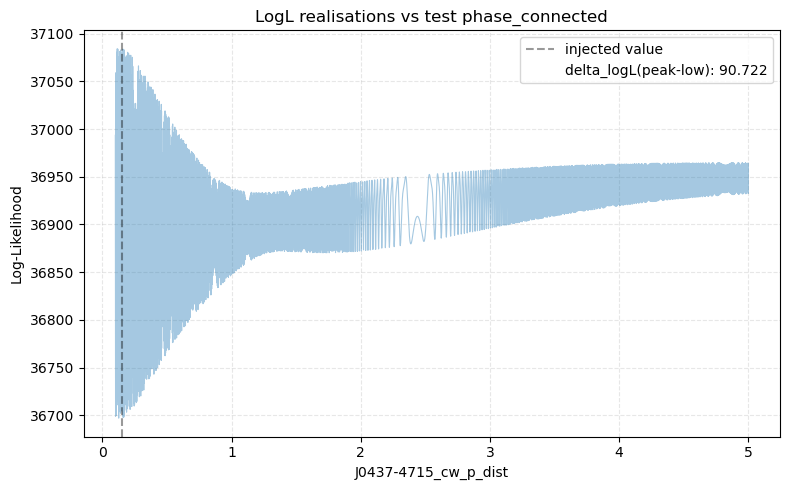

In [85]:

plot_key = reverse_temp_dict.get(scan_param, scan_param)

fig, ax = plt.subplots(figsize=(8, 5))
for curve in all_logls:
    ax.plot(scan_values, curve, alpha=0.4, linewidth=0.8)

likelihood_deltas = []
low_idx = int(np.argmin(scan_values))
for curve in all_logls:
    peak_idx = int(np.argmax(curve))
    likelihood_deltas.append(curve[peak_idx] - curve[low_idx])

legend_handles = []
legend_labels = []

if plot_key in enterprise_params:
    inj_line = ax.axvline(
        enterprise_params[plot_key], color="k", linestyle="--", label="injected value", alpha=0.4,
    )
    legend_handles.append(inj_line)
    legend_labels.append("injected value")

if likelihood_deltas:
    if len(likelihood_deltas) > 1:
        delta_value = float(np.mean(likelihood_deltas))
        delta_label = f"delta_logL_avg(peak-low): {delta_value:.3f}"
    else:
        delta_label = f"delta_logL(peak-low): {likelihood_deltas[0]:.3f}"
    dummy_handle = ax.plot([], [], " ", label=delta_label)[0]
    legend_handles.append(dummy_handle)
    legend_labels.append(dummy_handle.get_label())

if legend_handles:
    ax.legend(legend_handles, legend_labels)
ax.set_xlabel(scan_param)
ax.set_ylabel("Log-Likelihood")
ax.set_title(f"LogL realisations vs test phase_connected")
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()

In [90]:
enterprise_params

{'B1855+09_rednoise_log10_A': -14.759258254210852,
 'B1937+21_rednoise_log10_A': -16.285736693604232,
 'B1953+29_rednoise_log10_A': -15.562406563964663,
 'J0023+0923_rednoise_log10_A': -12.804058185298999,
 'J0030+0451_rednoise_log10_A': -12.89470276280285,
 'J0125-2327_rednoise_log10_A': -14.985140927237374,
 'J0340+4130_rednoise_log10_A': -13.177553830815738,
 'J0406+3039_rednoise_log10_A': -17.691435063744212,
 'J0437-4715_rednoise_log10_A': -17.83712123973376,
 'J0509+0856_rednoise_log10_A': -14.185557196835031,
 'J0557+1551_rednoise_log10_A': -15.73670304073626,
 'J0605+3757_rednoise_log10_A': -13.31620559258447,
 'J0610-2100_rednoise_log10_A': -15.825991254833816,
 'J0613-0200_rednoise_log10_A': -14.052795997433964,
 'J0614-3329_rednoise_log10_A': -13.66724281771264,
 'J0636+5128_rednoise_log10_A': -11.8380458980875,
 'J0636-3044_rednoise_log10_A': -11.613619354708351,
 'J0645+5158_rednoise_log10_A': -17.07543283815976,
 'J0709+0458_rednoise_log10_A': -14.789535203400579,
 'J0711